# Real World Experiment

This notebook runs experiments on real-world tabular datasets (e.g., Breast Cancer, Wine).

This notebook is part of the experimental pipeline for the paper 'Where Can I Trust You? Teacher-Surrogate Disagreement is Spatially Structured'.

In [1]:
%pip install numpy pandas matplotlib scikit-learn torch scipy -q



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Tabular Dataset Preprocessing

We load the Breast Cancer and Wine datasets from scikit-learn, apply standard scaling, and perform PCA to allow for 2D visualization of the decision boundaries.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.spatial import cKDTree

from sklearn.datasets import load_breast_cancer, load_wine, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


In [3]:
BASE_SEED = 42
np.random.seed(BASE_SEED)
torch.manual_seed(BASE_SEED)
DEVICE = "cpu"
print("Using device:", DEVICE)


Using device: cpu


### Real-World Disagreement Stratification

We compute the fidelity metrics and stratify the disagreements by the teacher's confidence, verifying that the spatial structure of disagreement observed in synthetic data holds true for real clinical data.

In [4]:
# -----------------------------------------------------------------------------
# Real-world / semi-real-world binary datasets
# -----------------------------------------------------------------------------
# Goal:
#   Show that the fidelity phenomenon is not merely an artifact of synthetic 2D
#   geometry. These are real tabular/image-feature datasets from sklearn.
#
# Datasets:
#   1. breast_cancer: real medical tabular binary classification
#   2. wine_binary: real tabular binary subset of wine classes 0 vs 1
#   3. digits_3_vs_8: real image-feature binary classification using 8x8 digits
#
# For geometry-weighted fidelity, we use a PCA projection to 2D only for
# approximate boundary geometry. The teacher/surrogate are trained on full
# standardized feature space. This intentionally tests whether the phenomenon
# survives when geometry is less directly observable.


def load_real_dataset(name):
    if name == "breast_cancer":
        data = load_breast_cancer()
        X = data.data
        y = data.target
        return X, y

    if name == "wine_binary":
        data = load_wine()
        X = data.data
        y = data.target
        mask = y < 2
        return X[mask], y[mask]

    if name == "digits_3_vs_8":
        data = load_digits()
        X = data.data
        y = data.target
        mask = (y == 3) | (y == 8)
        X = X[mask]
        y = (y[mask] == 8).astype(int)
        return X, y

    raise ValueError(f"Unknown real dataset: {name}")


### Random Forest Teacher & Logistic Surrogate

We train a Random Forest classifier as the complex teacher model, and attempt to explain its behavior globally using a simpler Logistic Regression surrogate.

In [5]:
# -----------------------------------------------------------------------------
# Teacher model
# -----------------------------------------------------------------------------

class TeacherMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_teacher(X_train, y_train, seed=42, epochs=500, batch_size=64, lr=1e-3):
    torch.manual_seed(seed)
    np.random.seed(seed)

    X_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_tensor = torch.tensor(y_train, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=batch_size, shuffle=True)

    model = TeacherMLP(input_dim=X_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()

    return model


def teacher_probs(model, X):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        logits = model(X_tensor)
        return torch.sigmoid(logits).cpu().numpy()


In [6]:
# -----------------------------------------------------------------------------
# Surrogate models
# -----------------------------------------------------------------------------

def fit_surrogate(name, X_train, teacher_train_y, seed=42):
    if name == "logistic_regression":
        model = LogisticRegression(max_iter=3000, random_state=seed)
    elif name == "linear_svm_calibrated":
        base = LinearSVC(max_iter=5000, random_state=seed)
        model = CalibratedClassifierCV(base, method="sigmoid", cv=3)
    elif name == "decision_tree_depth_2":
        model = DecisionTreeClassifier(max_depth=2, random_state=seed)
    elif name == "decision_tree_depth_4":
        model = DecisionTreeClassifier(max_depth=4, random_state=seed)
    elif name == "small_mlp_surrogate":
        model = MLPClassifier(
            hidden_layer_sizes=(12,),
            activation="relu",
            solver="adam",
            max_iter=3000,
            random_state=seed,
        )
    else:
        raise ValueError(f"Unknown surrogate: {name}")

    model.fit(X_train, teacher_train_y)
    return model


def surrogate_probs(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    scores = model.decision_function(X)
    return 1.0 / (1.0 + np.exp(-scores))


In [7]:
# -----------------------------------------------------------------------------
# Fidelity and weighting functions
# -----------------------------------------------------------------------------

def hard_agreement(teacher_p, surrogate_p):
    teacher_y = (teacher_p >= 0.5).astype(int)
    surrogate_y = (surrogate_p >= 0.5).astype(int)
    return (teacher_y == surrogate_y).astype(float)


def teacher_margin(teacher_p):
    return np.abs(teacher_p - 0.5)


def normalized_weighted_average(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights >= 0)

    if valid.sum() == 0 or weights[valid].sum() == 0:
        return np.nan

    return float(np.sum(values[valid] * weights[valid]) / np.sum(weights[valid]))


def confidence_weights(teacher_p, alpha=10.0):
    return np.exp(-alpha * teacher_margin(teacher_p))


def geometry_weights(boundary_distances, beta=2.0):
    return np.exp(-beta * boundary_distances)


In [8]:
# -----------------------------------------------------------------------------
# Geometry approximation in 2D PCA space
# -----------------------------------------------------------------------------
# Important limitation:
#   This is NOT exact high-dimensional distance to the teacher boundary.
#   It is an approximate geometry probe in a 2D PCA projection.
#   That is intentional: this experiment asks whether the phenomenon survives
#   when geometry is less directly observable than in synthetic 2D data.


def fit_pca_projection(X_train, X_test):
    pca = PCA(n_components=2, random_state=BASE_SEED)
    Z_train = pca.fit_transform(X_train)
    Z_test = pca.transform(X_test)
    return pca, Z_train, Z_test


def make_pca_grid(Z_reference, margin=0.75, grid_size=250):
    z0_min = Z_reference[:, 0].min() - margin
    z0_max = Z_reference[:, 0].max() + margin
    z1_min = Z_reference[:, 1].min() - margin
    z1_max = Z_reference[:, 1].max() + margin

    zz0, zz1 = np.meshgrid(
        np.linspace(z0_min, z0_max, grid_size),
        np.linspace(z1_min, z1_max, grid_size),
    )
    grid_z = np.c_[zz0.ravel(), zz1.ravel()]
    return zz0, zz1, grid_z


def approximate_projected_boundary_points(
    teacher,
    pca,
    Z_reference,
    grid_size=250,
    band_eps=0.025,
    fallback_k=1500,
):
    zz0, zz1, grid_z = make_pca_grid(Z_reference, grid_size=grid_size)

    # Inverse transform PCA grid back to original standardized feature space,
    # then query the full teacher model.
    grid_x_approx = pca.inverse_transform(grid_z)
    grid_p = teacher_probs(teacher, grid_x_approx)
    margins = np.abs(grid_p - 0.5)

    boundary_points_z = grid_z[margins <= band_eps]
    used_fallback = False

    if len(boundary_points_z) < 50:
        used_fallback = True
        k = min(fallback_k, len(grid_z))
        closest_idx = np.argpartition(margins, k - 1)[:k]
        boundary_points_z = grid_z[closest_idx]

    return {
        "zz0": zz0,
        "zz1": zz1,
        "grid_z": grid_z,
        "grid_p": grid_p,
        "grid_margins": margins,
        "boundary_points_z": boundary_points_z,
        "n_boundary_points": len(boundary_points_z),
        "used_fallback": used_fallback,
    }


def nearest_projected_boundary_distances(Z_eval, boundary_points_z):
    tree = cKDTree(boundary_points_z)
    distances, _ = tree.query(Z_eval, k=1)
    return distances


In [9]:
# -----------------------------------------------------------------------------
# Single run
# -----------------------------------------------------------------------------

def run_one_case(dataset_name, seed, surrogate_name, alpha=10.0, beta=2.0):
    X_raw, y = load_real_dataset(dataset_name)
    X_raw = np.asarray(X_raw, dtype=float)
    y = np.asarray(y, dtype=int)

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_raw,
        y,
        test_size=0.35,
        random_state=seed,
        stratify=y,
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    teacher = train_teacher(X_train, y_train, seed=seed)
    teacher_train_p = teacher_probs(teacher, X_train)
    teacher_train_y = (teacher_train_p >= 0.5).astype(int)
    teacher_test_p = teacher_probs(teacher, X_test)
    teacher_test_y = (teacher_test_p >= 0.5).astype(int)

    surrogate = fit_surrogate(surrogate_name, X_train, teacher_train_y, seed=seed)
    surrogate_test_p = surrogate_probs(surrogate, X_test)
    surrogate_test_y = (surrogate_test_p >= 0.5).astype(int)

    pca, Z_train, Z_test = fit_pca_projection(X_train, X_test)
    Z_all = np.vstack([Z_train, Z_test])
    boundary_info = approximate_projected_boundary_points(
        teacher,
        pca,
        Z_reference=Z_all,
    )

    projected_distances = nearest_projected_boundary_distances(
        Z_test,
        boundary_info["boundary_points_z"],
    )

    agreement = hard_agreement(teacher_test_p, surrogate_test_p)
    conf_w = confidence_weights(teacher_test_p, alpha=alpha)
    geo_w = geometry_weights(projected_distances, beta=beta)
    boundary_mask = teacher_margin(teacher_test_p) <= 0.10

    global_fid = float(np.mean(agreement))
    boundary_fid = float(np.mean(agreement[boundary_mask])) if boundary_mask.sum() > 0 else np.nan
    conf_fid = normalized_weighted_average(agreement, conf_w)
    geo_fid = normalized_weighted_average(agreement, geo_w)

    corr = stats.spearmanr(teacher_margin(teacher_test_p), projected_distances).correlation

    row = {
        "dataset": dataset_name,
        "seed": seed,
        "surrogate": surrogate_name,
        "n_samples": len(X_raw),
        "n_features": X_raw.shape[1],
        "teacher_task_accuracy": accuracy_score(y_test, teacher_test_y),
        "surrogate_task_accuracy": accuracy_score(y_test, surrogate_test_y),
        "global_fidelity": global_fid,
        "boundary_fidelity": boundary_fid,
        "boundary_fraction": float(boundary_mask.mean()),
        "confidence_weighted_fidelity": conf_fid,
        "projected_geometry_weighted_fidelity": geo_fid,
        "global_minus_confidence": global_fid - conf_fid,
        "global_minus_projected_geometry": global_fid - geo_fid,
        "confidence_minus_projected_geometry": conf_fid - geo_fid,
        "margin_projected_distance_spearman": corr,
        "pca_explained_variance_ratio_sum": float(np.sum(pca.explained_variance_ratio_)),
        "n_projected_boundary_points": boundary_info["n_boundary_points"],
        "used_boundary_fallback": boundary_info["used_fallback"],
    }

    case = {
        "dataset": dataset_name,
        "seed": seed,
        "surrogate": surrogate_name,
        "X_train": X_train,
        "X_test": X_test,
        "Z_train": Z_train,
        "Z_test": Z_test,
        "y_test": y_test,
        "teacher_test_p": teacher_test_p,
        "surrogate_test_p": surrogate_test_p,
        "projected_distances": projected_distances,
        "agreement": agreement,
        "boundary_info": boundary_info,
        "pca": pca,
    }

    return row, case


In [10]:
# -----------------------------------------------------------------------------
# Run real-data experiment
# -----------------------------------------------------------------------------

DATASETS = [
    "breast_cancer",
    "wine_binary",
    "digits_3_vs_8",
]

SURROGATES = [
    "logistic_regression",
    "linear_svm_calibrated",
    "decision_tree_depth_2",
    "decision_tree_depth_4",
    "small_mlp_surrogate",
]

SEEDS = list(range(10))

rows = []
example_cases = {}

for dataset_name in DATASETS:
    print(f"\n=== Dataset: {dataset_name} ===")
    for seed in SEEDS:
        print(f"  seed {seed}")
        for surrogate_name in SURROGATES:
            row, case = run_one_case(dataset_name, seed, surrogate_name)
            rows.append(row)
            if seed == 0 and surrogate_name == "logistic_regression":
                example_cases[dataset_name] = case

results = pd.DataFrame(rows)
results



=== Dataset: breast_cancer ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4
  seed 5
  seed 6
  seed 7
  seed 8
  seed 9

=== Dataset: wine_binary ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4
  seed 5
  seed 6
  seed 7
  seed 8
  seed 9

=== Dataset: digits_3_vs_8 ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4
  seed 5
  seed 6
  seed 7
  seed 8
  seed 9


,dataset,seed,surrogate,n_samples,n_features,teacher_task_accuracy,surrogate_task_accuracy,global_fidelity,boundary_fidelity,boundary_fraction,confidence_weighted_fidelity,projected_geometry_weighted_fidelity,global_minus_confidence,global_minus_projected_geometry,confidence_minus_projected_geometry,margin_projected_distance_spearman,pca_explained_variance_ratio_sum,n_projected_boundary_points,used_boundary_fallback
0,breast_cancer,0,logistic_regression,569,30,0.960,0.970,0.980,0.0,0.005,0.782951,0.895557,0.197049,0.084443,-0.112606,0.617181,0.638139,1500,True
1,breast_cancer,0,linear_svm_calibrated,569,30,0.960,0.980,0.980,0.0,0.005,0.782956,0.899274,0.197044,0.080726,-0.116318,0.617181,0.638139,1500,True
2,breast_cancer,0,decision_tree_depth_2,569,30,0.960,0.930,0.910,0.0,0.005,0.659302,0.563073,0.250698,0.346927,0.096228,0.617181,0.638139,1500,True
3,breast_cancer,0,decision_tree_depth_4,569,30,0.960,0.940,0.940,1.0,0.005,0.879237,0.737223,0.060763,0.202777,0.142013,0.617181,0.638139,1500,True
4,breast_cancer,0,small_mlp_surrogate,569,30,0.960,0.965,0.985,1.0,0.005,0.988713,0.915907,-0.003713,0.069093,0.072806,0.617181,0.638139,1500,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,digits_3_vs_8,9,logistic_regression,357,64,0.992,0.976,0.984,NaN,0.000,0.881875,0.981646,0.102125,0.002354,-0.099772,0.661996,0.269870,113,False
146,digits_3_vs_8,9,linear_svm_calibrated,357,64,0.992,0.976,0.984,NaN,0.000,0.987559,0.997346,-0.003559,-0.013346,-0.009787,0.661996,0.269870,113,False
147,digits_3_vs_8,9,decision_tree_depth_2,357,64,0.992,0.912,0.904,NaN,0.000,0.735149,0.799211,0.168851,0.104789,-0.064062,0.661996,0.269870,113,False
148,digits_3_vs_8,9,decision_tree_depth_4,357,64,0.992,0.944,0.936,NaN,0.000,0.758515,0.810030,0.177485,0.125970,-0.051515,0.661996,0.269870,113,False


### Artifact Export

Saving the tabular results and figures for downstream inclusion in the paper.

In [11]:
results.to_csv("real_world_experiment_results.csv", index=False)
print("Saved real_world_experiment_results.csv")


Saved real_world_experiment_results.csv


In [12]:
# -----------------------------------------------------------------------------
# Aggregate summaries
# -----------------------------------------------------------------------------

summary = (
    results
    .groupby("dataset")
    .agg(
        n_samples=("n_samples", "mean"),
        n_features=("n_features", "mean"),
        teacher_task_accuracy_mean=("teacher_task_accuracy", "mean"),
        surrogate_task_accuracy_mean=("surrogate_task_accuracy", "mean"),
        global_fidelity_mean=("global_fidelity", "mean"),
        boundary_fidelity_mean=("boundary_fidelity", "mean"),
        boundary_fraction_mean=("boundary_fraction", "mean"),
        confidence_weighted_mean=("confidence_weighted_fidelity", "mean"),
        projected_geometry_weighted_mean=("projected_geometry_weighted_fidelity", "mean"),
        global_minus_confidence_mean=("global_minus_confidence", "mean"),
        global_minus_projected_geometry_mean=("global_minus_projected_geometry", "mean"),
        confidence_minus_projected_geometry_mean=("confidence_minus_projected_geometry", "mean"),
        margin_projected_distance_spearman_mean=("margin_projected_distance_spearman", "mean"),
        pca_explained_variance_ratio_sum_mean=("pca_explained_variance_ratio_sum", "mean"),
        projected_boundary_points_mean=("n_projected_boundary_points", "mean"),
        boundary_fallback_rate=("used_boundary_fallback", "mean"),
    )
    .reset_index()
)

summary


,dataset,n_samples,n_features,teacher_task_accuracy_mean,surrogate_task_accuracy_mean,global_fidelity_mean,boundary_fidelity_mean,boundary_fraction_mean,confidence_weighted_mean,projected_geometry_weighted_mean,global_minus_confidence_mean,global_minus_projected_geometry_mean,confidence_minus_projected_geometry_mean,margin_projected_distance_spearman_mean,pca_explained_variance_ratio_sum_mean,projected_boundary_points_mean,boundary_fallback_rate
0,breast_cancer,569.0,30.0,0.972000,0.954700,0.962100,0.52,0.004000,0.839548,0.850527,0.122552,0.111573,-0.010980,0.549190,0.635337,1500.0,1.0
1,digits_3_vs_8,357.0,64.0,0.992000,0.965440,0.965440,0.50,0.001600,0.883205,0.932832,0.082235,0.032608,-0.049627,0.672237,0.267828,117.1,0.0
2,wine_binary,130.0,13.0,0.980435,0.970435,0.968261,0.40,0.002174,0.874594,0.904723,0.093666,0.063538,-0.030128,0.729943,0.511920,160.8,0.0


In [13]:
summary.to_csv("real_world_experiment_summary.csv", index=False)
print("Saved real_world_experiment_summary.csv")


Saved real_world_experiment_summary.csv


In [14]:
# -----------------------------------------------------------------------------
# Surrogate-level summary
# -----------------------------------------------------------------------------

surrogate_summary = (
    results
    .groupby(["dataset", "surrogate"])
    .agg(
        global_fidelity_mean=("global_fidelity", "mean"),
        boundary_fidelity_mean=("boundary_fidelity", "mean"),
        confidence_weighted_mean=("confidence_weighted_fidelity", "mean"),
        projected_geometry_weighted_mean=("projected_geometry_weighted_fidelity", "mean"),
        global_minus_confidence_mean=("global_minus_confidence", "mean"),
        global_minus_projected_geometry_mean=("global_minus_projected_geometry", "mean"),
        confidence_minus_projected_geometry_mean=("confidence_minus_projected_geometry", "mean"),
        margin_projected_distance_spearman_mean=("margin_projected_distance_spearman", "mean"),
    )
    .reset_index()
)

surrogate_summary


,dataset,surrogate,global_fidelity_mean,boundary_fidelity_mean,confidence_weighted_mean,projected_geometry_weighted_mean,global_minus_confidence_mean,global_minus_projected_geometry_mean,confidence_minus_projected_geometry_mean,margin_projected_distance_spearman_mean
0,breast_cancer,decision_tree_depth_2,0.927500,0.4,0.798333,0.731447,0.129167,0.196053,0.066886,0.549190
1,breast_cancer,decision_tree_depth_4,0.940000,0.6,0.837655,0.769248,0.102345,0.170752,0.068407,0.549190
2,breast_cancer,linear_svm_calibrated,0.978500,0.5,0.838834,0.902792,0.139666,0.075708,-0.063958,0.549190
3,breast_cancer,logistic_regression,0.982500,0.5,0.849944,0.923318,0.132556,0.059182,-0.073374,0.549190
4,breast_cancer,small_mlp_surrogate,0.982000,0.6,0.872972,0.925830,0.109028,0.056170,-0.052859,0.549190
5,digits_3_vs_8,decision_tree_depth_2,0.924800,0.0,0.788901,0.873354,0.135899,0.051446,-0.084452,0.672237
6,digits_3_vs_8,decision_tree_depth_4,0.926400,0.0,0.789154,0.846721,0.137246,0.079679,-0.057567,0.672237
7,digits_3_vs_8,linear_svm_calibrated,0.993600,0.5,0.924071,0.990572,0.069529,0.003028,-0.066501,0.672237
8,digits_3_vs_8,logistic_regression,0.995200,1.0,0.967273,0.990151,0.027927,0.005049,-0.022878,0.672237
9,digits_3_vs_8,small_mlp_surrogate,0.987200,1.0,0.946626,0.963363,0.040574,0.023837,-0.016737,0.672237


In [15]:
surrogate_summary.to_csv("real_world_experiment_surrogate_summary.csv", index=False)
print("Saved real_world_experiment_surrogate_summary.csv")


Saved real_world_experiment_surrogate_summary.csv


### Visualization

Finally, we visualize the spatial structure of teacher-surrogate disagreement to demonstrate the impact of locality weighting.

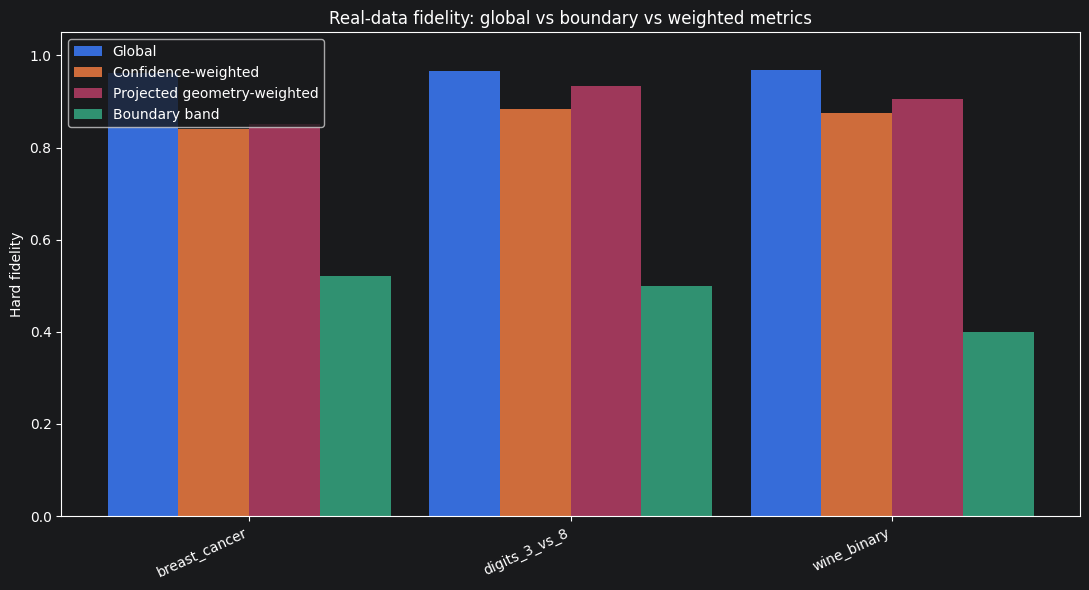

In [16]:
# -----------------------------------------------------------------------------
# Plot: global vs boundary vs weighted fidelity
# -----------------------------------------------------------------------------

ordered = summary["dataset"].tolist()
positions = np.arange(len(ordered))
width = 0.22

fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(
    positions - 1.5 * width,
    [summary.loc[summary["dataset"] == d, "global_fidelity_mean"].iloc[0] for d in ordered],
    width,
    label="Global",
)
ax.bar(
    positions - 0.5 * width,
    [summary.loc[summary["dataset"] == d, "confidence_weighted_mean"].iloc[0] for d in ordered],
    width,
    label="Confidence-weighted",
)
ax.bar(
    positions + 0.5 * width,
    [summary.loc[summary["dataset"] == d, "projected_geometry_weighted_mean"].iloc[0] for d in ordered],
    width,
    label="Projected geometry-weighted",
)
ax.bar(
    positions + 1.5 * width,
    [summary.loc[summary["dataset"] == d, "boundary_fidelity_mean"].iloc[0] for d in ordered],
    width,
    label="Boundary band",
)

ax.set_xticks(positions)
ax.set_xticklabels(ordered, rotation=25, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Hard fidelity")
ax.set_title("Real-data fidelity: global vs boundary vs weighted metrics")
ax.legend()

plt.tight_layout()
plt.savefig("real_world_global_boundary_weighted_comparison.png", dpi=200)
plt.show()


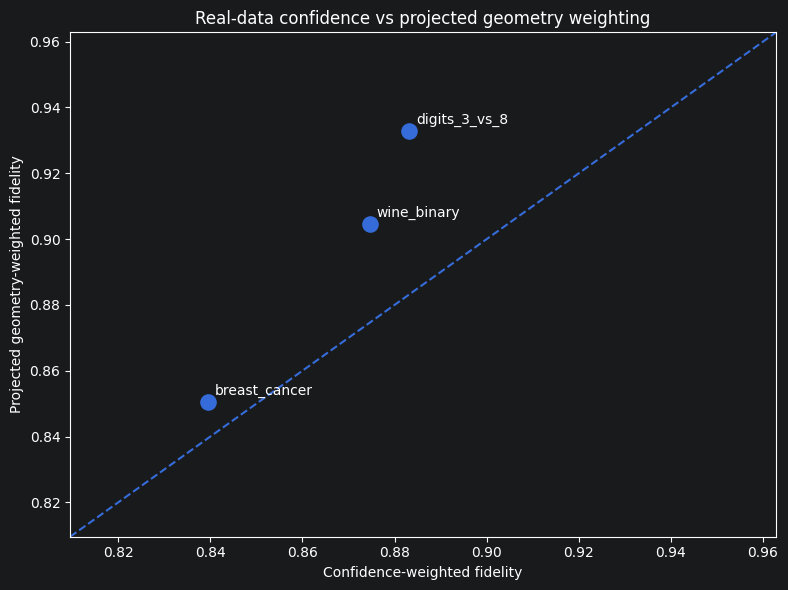

In [17]:
# -----------------------------------------------------------------------------
# Plot: confidence vs projected geometry weighting
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    summary["confidence_weighted_mean"],
    summary["projected_geometry_weighted_mean"],
    s=120,
)

for _, row in summary.iterrows():
    ax.annotate(
        row["dataset"],
        (row["confidence_weighted_mean"], row["projected_geometry_weighted_mean"]),
        xytext=(5, 5),
        textcoords="offset points",
    )

lo = min(summary["confidence_weighted_mean"].min(), summary["projected_geometry_weighted_mean"].min()) - 0.03
hi = max(summary["confidence_weighted_mean"].max(), summary["projected_geometry_weighted_mean"].max()) + 0.03
ax.plot([lo, hi], [lo, hi], linestyle="--")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel("Confidence-weighted fidelity")
ax.set_ylabel("Projected geometry-weighted fidelity")
ax.set_title("Real-data confidence vs projected geometry weighting")

plt.tight_layout()
plt.savefig("real_world_confidence_vs_projected_geometry.png", dpi=200)
plt.show()


In [18]:
# -----------------------------------------------------------------------------
# Plot: PCA geometry examples
# -----------------------------------------------------------------------------

def plot_example_case(dataset_name):
    case = example_cases[dataset_name]
    Z_test = case["Z_test"]
    y_test = case["y_test"]
    teacher_p = case["teacher_test_p"]
    distances = case["projected_distances"]
    boundary_info = case["boundary_info"]

    zz0 = boundary_info["zz0"]
    zz1 = boundary_info["zz1"]
    grid_p = boundary_info["grid_p"].reshape(zz0.shape)
    boundary_points_z = boundary_info["boundary_points_z"]

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    axes[0].contourf(zz0, zz1, grid_p, levels=30, alpha=0.85)
    axes[0].contour(zz0, zz1, grid_p, levels=[0.5], linewidths=2)
    axes[0].scatter(Z_test[:, 0], Z_test[:, 1], c=y_test, s=18, edgecolor="k", linewidth=0.2)
    axes[0].set_title("Teacher probability in PCA plane")

    axes[1].scatter(boundary_points_z[:, 0], boundary_points_z[:, 1], s=3)
    axes[1].scatter(Z_test[:, 0], Z_test[:, 1], c=y_test, s=18, alpha=0.35)
    axes[1].set_title(f"Approx. projected boundary points (n={len(boundary_points_z)})")

    axes[2].scatter(teacher_margin(teacher_p), distances, s=20, alpha=0.7)
    axes[2].set_xlabel("Teacher margin |p-0.5|")
    axes[2].set_ylabel("Projected distance to boundary")
    axes[2].set_title("Margin vs projected geometry distance")

    for ax in axes[:2]:
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(f"Projected geometry example: {dataset_name}", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"real_world_projected_geometry_example_{dataset_name}.png", dpi=200)
    plt.show()


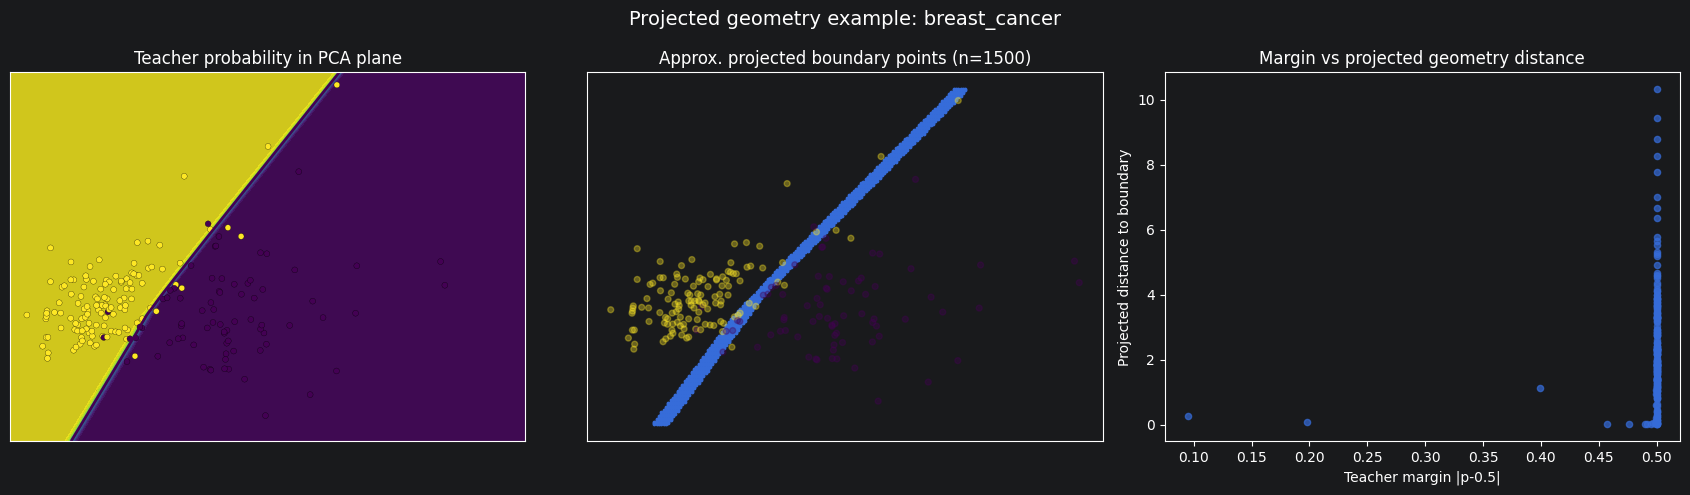

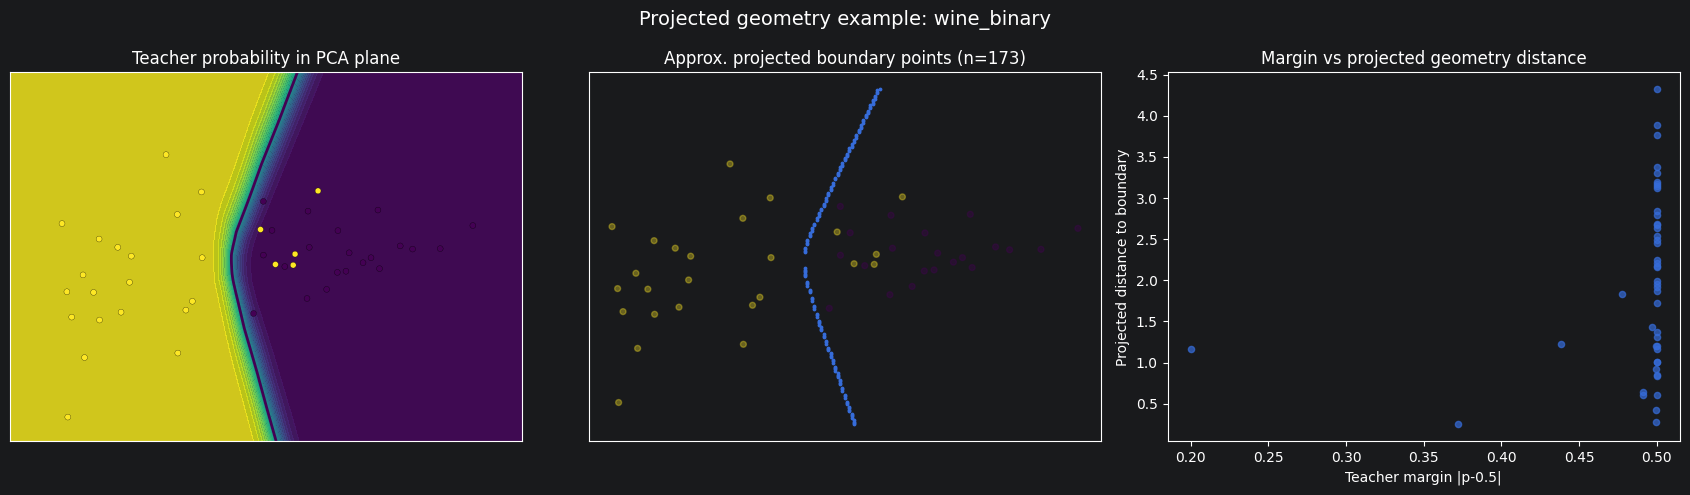

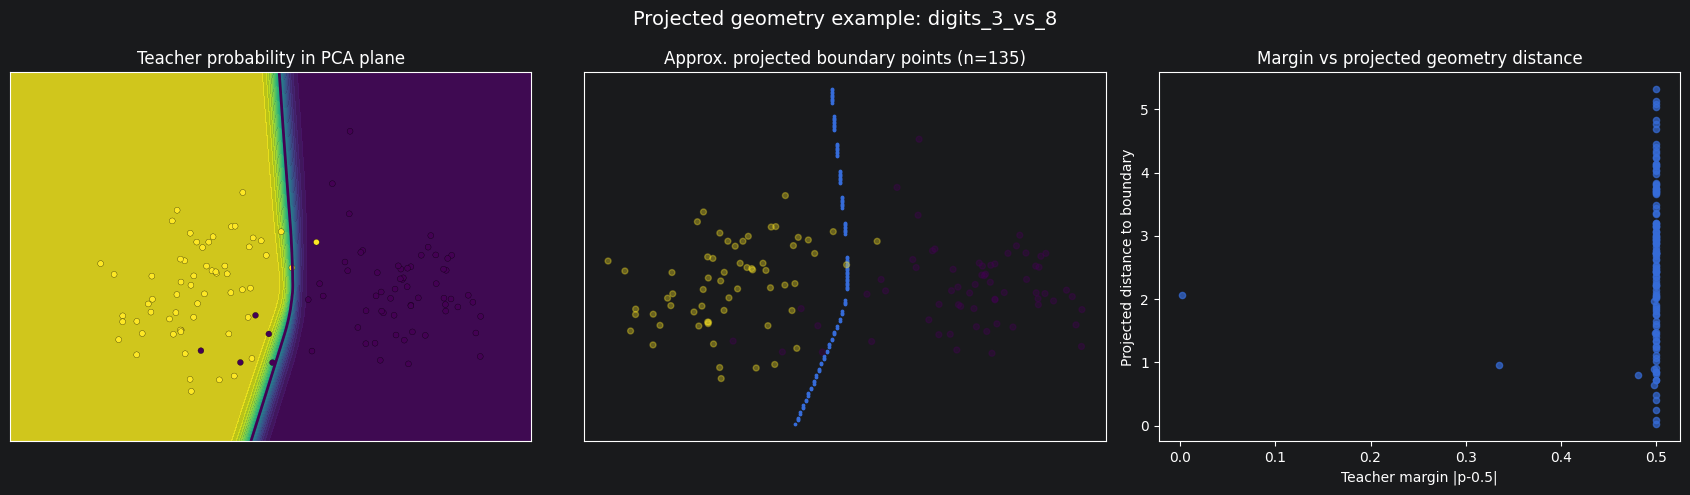

In [19]:
for dataset_name in DATASETS:
    plot_example_case(dataset_name)


In [20]:
print("Questions addressed by this notebook:")
print("1. Does the global-vs-boundary fidelity gap appear on real datasets?")
print("2. Does confidence weighting still reduce global overstatement outside synthetic data?")
print("3. Does a projected geometry proxy reveal additional structure beyond confidence?")
print("4. Is the phenomenon plausibly not just an artifact of perfectly observable 2D synthetic geometry?")

print("\nImportant limitation:")
print("Projected geometry weighting uses a 2D PCA approximation. It is not exact high-dimensional distance to the teacher boundary.")

Questions addressed by this notebook:
1. Does the global-vs-boundary fidelity gap appear on real datasets?
2. Does confidence weighting still reduce global overstatement outside synthetic data?
3. Does a projected geometry proxy reveal additional structure beyond confidence?
4. Is the phenomenon plausibly not just an artifact of perfectly observable 2D synthetic geometry?

Important limitation:
Projected geometry weighting uses a 2D PCA approximation. It is not exact high-dimensional distance to the teacher boundary.
